# Generic Polymarket Compare Analysis
Use this notebook for any combined compare JSON with the same schema as `iran_hourly.json` or `polymarket-compare-2026-04-11.json`.

In [24]:
import json
from itertools import combinations
from pathlib import Path

try:
    import piplite
except ImportError:
    piplite = None

if piplite is not None:
    await piplite.install("seaborn")

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.max_columns = 500

BASE_DIR = Path.cwd()
SUPPORTED_SCHEMA_TYPE = "polymarket_combined_compare"

def slug_to_title(text: str) -> str:
    return text.replace("_", " ").replace("-", " ").strip().title()

def wrap_labels(labels, width: int = 55):
    return [label if len(label) <= width else label[: width - 3] + "..." for label in labels]

def infer_rolling_window(index: pd.DatetimeIndex) -> str:
    if len(index) < 2:
        return "7D"

    deltas = index.to_series().sort_values().diff().dropna()
    median_delta = deltas.median()

    if pd.isna(median_delta):
        return "7D"
    if median_delta <= pd.Timedelta(hours=1):
        return "24h"
    if median_delta <= pd.Timedelta(days=1):
        return "7D"
    return "30D"

def list_compare_json_files(base_dir: Path) -> list[Path]:
    return sorted(
        path
        for path in base_dir.glob("*.json")
        if path.is_file()
    )

def load_compare_json(path: str | Path):
    path = Path(path)
    payload = json.loads(path.read_text())

    if payload.get("type") != SUPPORTED_SCHEMA_TYPE:
        raise ValueError(
            f"Unsupported schema type {payload.get('type')!r}. Expected {SUPPORTED_SCHEMA_TYPE!r}."
        )

    rows = []
    for series in payload["series"]:
        market_name = series["name"]
        for point in series["points"]:
            rows.append(
                {
                    "market": market_name,
                    "timestamp": pd.to_datetime(point["t"], unit="s", utc=True),
                    "price": float(point["p"]),
                }
            )

    long_df = pd.DataFrame(rows).sort_values(["timestamp", "market"]).reset_index(drop=True)
    market_df = (
        long_df.pivot_table(
            index="timestamp",
            columns="market",
            values="price",
            aggfunc="last",
        )
        .sort_index()
        .astype(float)
    )

    return payload, long_df, market_df

In [25]:
AVAILABLE_DATA_FILES = [path.name for path in list_compare_json_files(BASE_DIR)]
display(pd.DataFrame({"available_compare_files": AVAILABLE_DATA_FILES}))

DATA_FILE = "iran_hourly.json"
DATA_PATH = BASE_DIR / DATA_FILE

if DATA_FILE not in AVAILABLE_DATA_FILES:
    raise FileNotFoundError(
        f"{DATA_FILE!r} was not found in {BASE_DIR}. Choose one of: {AVAILABLE_DATA_FILES}"
    )

payload, long_df, market_df = load_compare_json(DATA_PATH)
analysis_title = slug_to_title(payload.get("type", DATA_PATH.stem))
frequency = payload.get("range", {}).get("frequency", "unknown")
rolling_window = infer_rolling_window(market_df.index)

print(f"Loaded {DATA_PATH.name}")
print(f"Series: {market_df.shape[1]} | Long rows: {len(long_df):,} | Frequency: {frequency}")
print(f"Date range: {market_df.index.min()} -> {market_df.index.max()}")
print(f"Rolling window: {rolling_window}")
display(pd.DataFrame(payload.get("range", {}), index=[0]))
display(market_df.head())

,available_compare_files
0,iran_hourly.json
1,marc.json
2,polymarket-compare-2026-02-01.json
3,polymarket-compare-2026-04-11.json
4,trump-out.json


Loaded iran_hourly.json
Series: 10 | Long rows: 4,436 | Frequency: hourly
Date range: 2026-03-06 22:00:00+00:00 -> 2026-04-11 19:00:00+00:00
Rolling window: 24h


,from_date,to_date,frequency
0,2026-02-28,2026-04-11,hourly


market,April 1 — Iran successfully targets shipping on...?,April 30 — Trump announces end of military operations against Iran by ...?,April 30 — Will Trump declare war on Iran by...?,April 30 — Will another country conduct military action against Iran by...?,April 6 — Iran military action against Israel on...?,April 8 — Iran military action against Israel on...?,April 9 — Military action against Iran ends on...?,March 22 — Iran military action against a Gulf State on...?,May 31 — Israel ground operation in Iran confirmed by...?,US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?
timestamp,,,,,,,,,,
2026-03-06 22:00:00+00:00,NaN,0.74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-06 23:00:00+00:00,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-07 00:00:00+00:00,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-07 01:00:00+00:00,NaN,0.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-07 02:00:00+00:00,NaN,0.51,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
df = market_df.sort_index().copy()
df = df.interpolate(method="time").ffill().bfill()

market_summary = (
    df.agg(["count", "mean", "std", "min", "max"]).T.sort_values("std", ascending=False)
    if not df.empty
    else pd.DataFrame()
 )

coverage_summary = (
    long_df.groupby("market").agg(
        observations=("price", "size"),
        first_seen=("timestamp", "min"),
        last_seen=("timestamp", "max"),
    ).sort_values(["observations", "market"], ascending=[False, True])
    if not long_df.empty
    else pd.DataFrame()
 )

df.info()
display(market_summary.head(10))
display(coverage_summary.head(10))
display(df.tail())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 862 entries, 2026-03-06 22:00:00+00:00 to 2026-04-11 19:00:00+00:00
Data columns (total 10 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   April 1 — Iran successfully targets shipping on...?                          862 non-null    float64
 1   April 30 — Trump announces end of military operations against Iran by ...?   862 non-null    float64
 2   April 30 — Will Trump declare war on Iran by...?                             862 non-null    float64
 3   April 30 — Will another country conduct military action against Iran by...?  862 non-null    float64
 4   April 6 — Iran military action against Israel on...?                         862 non-null    float64
 5   April 8 — Iran military action against Israel on...?                         862 non-null    float6

,count,mean,std,min,max
market,,,,,
April 1 — Iran successfully targets shipping on...?,862.0,0.451299,0.351732,0.0850,0.9995
March 22 — Iran military action against a Gulf State on...?,862.0,0.788683,0.262446,0.4150,0.9995
April 9 — Military action against Iran ends on...?,862.0,0.318678,0.245285,0.0055,0.9885
April 6 — Iran military action against Israel on...?,862.0,0.629372,0.241372,0.4150,0.9995
April 8 — Iran military action against Israel on...?,862.0,0.602095,0.219744,0.4150,0.9995
April 30 — Will Trump declare war on Iran by...?,862.0,0.299998,0.217787,0.0195,0.7150
April 30 — Trump announces end of military operations against Iran by ...?,862.0,0.519014,0.120191,0.2750,0.7750
April 30 — Will another country conduct military action against Iran by...?,862.0,0.334060,0.092675,0.0600,0.4750
US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,862.0,0.148972,0.074249,0.0245,0.3325


,observations,first_seen,last_seen
market,,,
April 30 — Trump announces end of military operations against Iran by ...?,862,2026-03-06 22:00:00+00:00,2026-04-11 19:00:00+00:00
US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,790,2026-03-09 22:00:00+00:00,2026-04-11 19:00:00+00:00
April 30 — Will another country conduct military action against Iran by...?,553,2026-03-19 19:00:00+00:00,2026-04-11 19:00:00+00:00
April 30 — Will Trump declare war on Iran by...?,432,2026-03-24 20:00:00+00:00,2026-04-11 19:00:00+00:00
April 8 — Iran military action against Israel on...?,369,2026-03-24 18:00:00+00:00,2026-04-09 02:00:00+00:00
April 9 — Military action against Iran ends on...?,361,2026-03-27 19:00:00+00:00,2026-04-11 19:00:00+00:00
April 1 — Iran successfully targets shipping on...?,324,2026-03-24 18:00:00+00:00,2026-04-07 05:00:00+00:00
April 6 — Iran military action against Israel on...?,321,2026-03-24 18:00:00+00:00,2026-04-07 02:00:00+00:00
May 31 — Israel ground operation in Iran confirmed by...?,266,2026-03-31 18:00:00+00:00,2026-04-11 19:00:00+00:00


market,April 1 — Iran successfully targets shipping on...?,April 30 — Trump announces end of military operations against Iran by ...?,April 30 — Will Trump declare war on Iran by...?,April 30 — Will another country conduct military action against Iran by...?,April 6 — Iran military action against Israel on...?,April 8 — Iran military action against Israel on...?,April 9 — Military action against Iran ends on...?,March 22 — Iran military action against a Gulf State on...?,May 31 — Israel ground operation in Iran confirmed by...?,US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?
timestamp,,,,,,,,,,
2026-04-11 15:00:00+00:00,0.9995,0.445,0.0420,0.150,0.9995,0.9995,0.9830,0.9995,0.115,0.2105
2026-04-11 16:00:00+00:00,0.9995,0.445,0.0425,0.145,0.9995,0.9995,0.9830,0.9995,0.115,0.2155
2026-04-11 17:00:00+00:00,0.9995,0.445,0.0425,0.140,0.9995,0.9995,0.9815,0.9995,0.120,0.2495
2026-04-11 18:00:00+00:00,0.9995,0.460,0.0430,0.150,0.9995,0.9995,0.9835,0.9995,0.120,0.2705
2026-04-11 19:00:00+00:00,0.9995,0.460,0.0425,0.145,0.9995,0.9995,0.9845,0.9995,0.120,0.2630


In [27]:
latest_snapshot = df.iloc[[-1]].T.rename(columns={df.index[-1]: "latest_price"})
latest_snapshot = latest_snapshot.sort_values("latest_price", ascending=False)

display(latest_snapshot.head(10))
df.tail()

timestamp,latest_price
market,
April 1 — Iran successfully targets shipping on...?,0.9995
April 6 — Iran military action against Israel on...?,0.9995
April 8 — Iran military action against Israel on...?,0.9995
March 22 — Iran military action against a Gulf State on...?,0.9995
April 9 — Military action against Iran ends on...?,0.9845
April 30 — Trump announces end of military operations against Iran by ...?,0.4600
US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,0.2630
April 30 — Will another country conduct military action against Iran by...?,0.1450
May 31 — Israel ground operation in Iran confirmed by...?,0.1200


market,April 1 — Iran successfully targets shipping on...?,April 30 — Trump announces end of military operations against Iran by ...?,April 30 — Will Trump declare war on Iran by...?,April 30 — Will another country conduct military action against Iran by...?,April 6 — Iran military action against Israel on...?,April 8 — Iran military action against Israel on...?,April 9 — Military action against Iran ends on...?,March 22 — Iran military action against a Gulf State on...?,May 31 — Israel ground operation in Iran confirmed by...?,US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?
timestamp,,,,,,,,,,
2026-04-11 15:00:00+00:00,0.9995,0.445,0.0420,0.150,0.9995,0.9995,0.9830,0.9995,0.115,0.2105
2026-04-11 16:00:00+00:00,0.9995,0.445,0.0425,0.145,0.9995,0.9995,0.9830,0.9995,0.115,0.2155
2026-04-11 17:00:00+00:00,0.9995,0.445,0.0425,0.140,0.9995,0.9995,0.9815,0.9995,0.120,0.2495
2026-04-11 18:00:00+00:00,0.9995,0.460,0.0430,0.150,0.9995,0.9995,0.9835,0.9995,0.120,0.2705
2026-04-11 19:00:00+00:00,0.9995,0.460,0.0425,0.145,0.9995,0.9995,0.9845,0.9995,0.120,0.2630


In [28]:
returns_df = df.diff()

print(f"Analysis frame shape: {df.shape}")
display(returns_df.tail())
display(df.tail(10))

Analysis frame shape: (862, 10)


market,April 1 — Iran successfully targets shipping on...?,April 30 — Trump announces end of military operations against Iran by ...?,April 30 — Will Trump declare war on Iran by...?,April 30 — Will another country conduct military action against Iran by...?,April 6 — Iran military action against Israel on...?,April 8 — Iran military action against Israel on...?,April 9 — Military action against Iran ends on...?,March 22 — Iran military action against a Gulf State on...?,May 31 — Israel ground operation in Iran confirmed by...?,US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?
timestamp,,,,,,,,,,
2026-04-11 15:00:00+00:00,0.0,0.010,-0.0005,-0.005,0.0,0.0,-0.0025,0.0,0.005,0.0015
2026-04-11 16:00:00+00:00,0.0,0.000,0.0005,-0.005,0.0,0.0,0.0000,0.0,0.000,0.0050
2026-04-11 17:00:00+00:00,0.0,0.000,0.0000,-0.005,0.0,0.0,-0.0015,0.0,0.005,0.0340
2026-04-11 18:00:00+00:00,0.0,0.015,0.0005,0.010,0.0,0.0,0.0020,0.0,0.000,0.0210
2026-04-11 19:00:00+00:00,0.0,0.000,-0.0005,-0.005,0.0,0.0,0.0010,0.0,0.000,-0.0075


market,April 1 — Iran successfully targets shipping on...?,April 30 — Trump announces end of military operations against Iran by ...?,April 30 — Will Trump declare war on Iran by...?,April 30 — Will another country conduct military action against Iran by...?,April 6 — Iran military action against Israel on...?,April 8 — Iran military action against Israel on...?,April 9 — Military action against Iran ends on...?,March 22 — Iran military action against a Gulf State on...?,May 31 — Israel ground operation in Iran confirmed by...?,US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?
timestamp,,,,,,,,,,
2026-04-11 10:00:00+00:00,0.9995,0.435,0.0430,0.160,0.9995,0.9995,0.9815,0.9995,0.110,0.1970
2026-04-11 11:00:00+00:00,0.9995,0.435,0.0435,0.155,0.9995,0.9995,0.9815,0.9995,0.110,0.2015
2026-04-11 12:00:00+00:00,0.9995,0.435,0.0435,0.155,0.9995,0.9995,0.9885,0.9995,0.110,0.2000
2026-04-11 13:00:00+00:00,0.9995,0.435,0.0430,0.155,0.9995,0.9995,0.9875,0.9995,0.110,0.2090
2026-04-11 14:00:00+00:00,0.9995,0.435,0.0425,0.155,0.9995,0.9995,0.9855,0.9995,0.110,0.2090
2026-04-11 15:00:00+00:00,0.9995,0.445,0.0420,0.150,0.9995,0.9995,0.9830,0.9995,0.115,0.2105
2026-04-11 16:00:00+00:00,0.9995,0.445,0.0425,0.145,0.9995,0.9995,0.9830,0.9995,0.115,0.2155
2026-04-11 17:00:00+00:00,0.9995,0.445,0.0425,0.140,0.9995,0.9995,0.9815,0.9995,0.120,0.2495
2026-04-11 18:00:00+00:00,0.9995,0.460,0.0430,0.150,0.9995,0.9995,0.9835,0.9995,0.120,0.2705


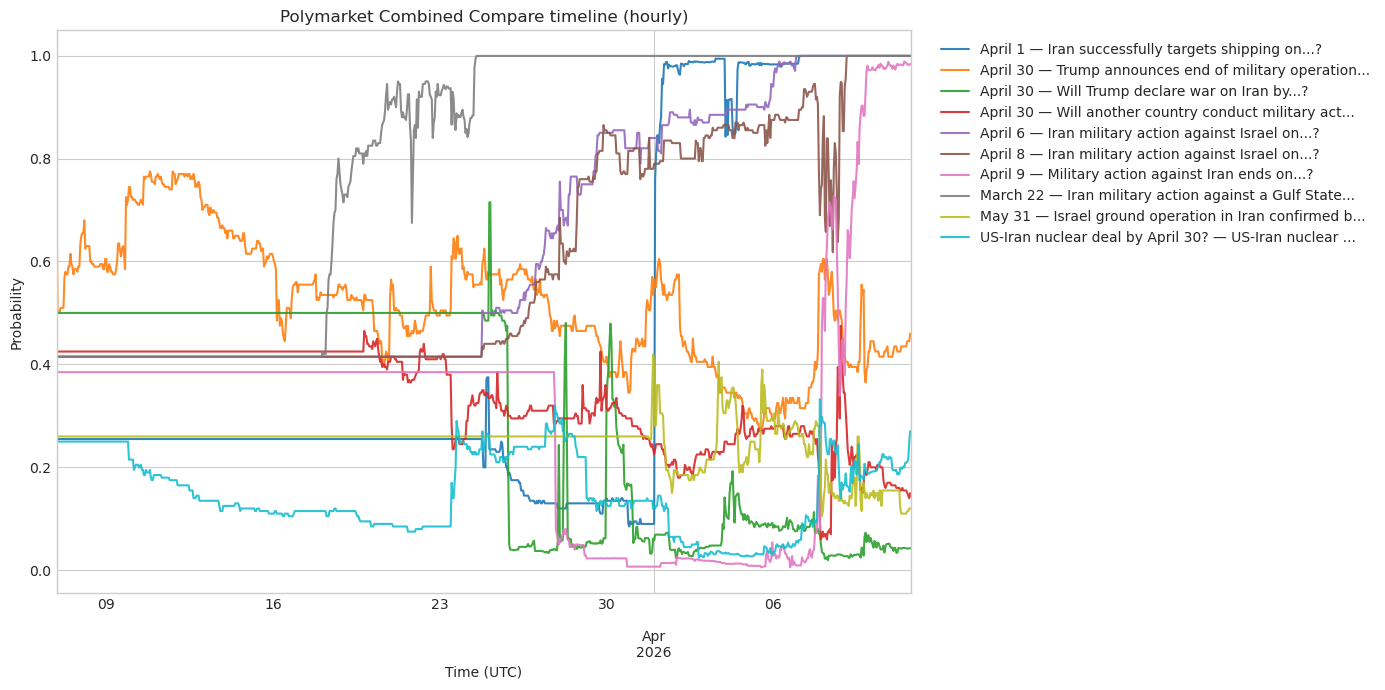

In [29]:
ax = df.plot(figsize=(14, 7), linewidth=1.5, alpha=0.9)
ax.set_title(f"{analysis_title} timeline ({frequency})")
ax.set_ylabel("Probability")
ax.set_xlabel("Time (UTC)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

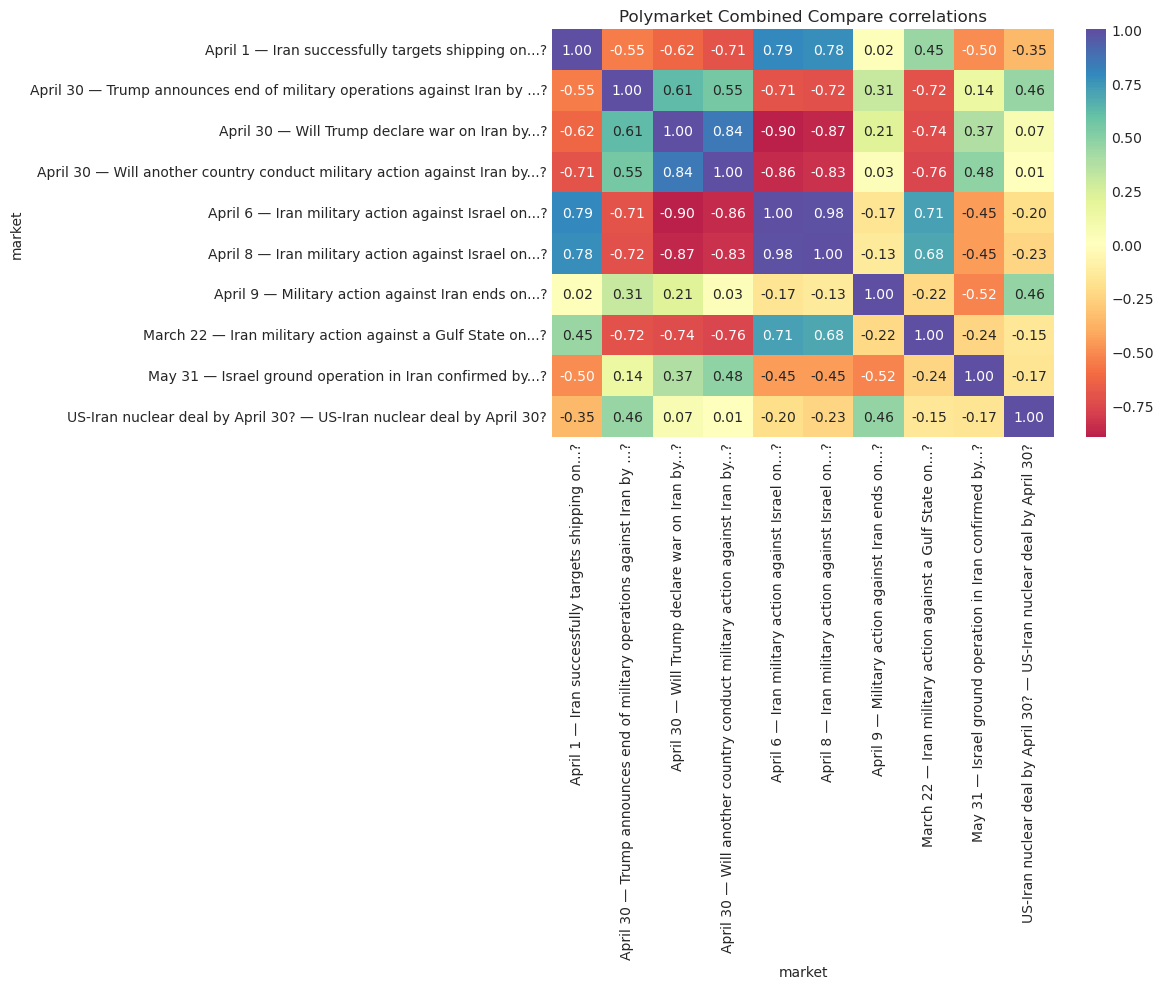

In [30]:
ct = df.corr()

if len(ct.columns) < 2:
    print("Need at least two markets for a correlation heatmap.")
else:
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        ct,
        annot=len(ct) <= 12,
        cmap="Spectral",
        center=0,
        fmt=".2f",
    )
    plt.title(f"{analysis_title} correlations")
    plt.tight_layout()
    plt.show()

In [31]:
rolling_min_periods = 2 if len(df) >= 2 else 1
rolling_corr = df.rolling(rolling_window, min_periods=rolling_min_periods).corr() if len(df.columns) >= 2 else pd.DataFrame()
display(rolling_corr.tail())

market                                                                        April 1 — Iran successfully targets shipping on...?  \
timestamp                 market                                                                                                    
2026-04-11 19:00:00+00:00 April 8 — Iran military action against Israel o...                                                NaN     
                          April 9 — Military action against Iran ends on...?                                                NaN     
                          March 22 — Iran military action against a Gulf ...                                                NaN     
                          May 31 — Israel ground operation in Iran confir...                                                NaN     
                          US-Iran nuclear deal by April 30? — US-Iran nuc...                                                NaN     

market                                                                        April 30 — Trump announces end of military operations against Iran by ...?  \
timestamp                 market                                                                                                                           
2026-04-11 19:00:00+00:00 April 8 — Iran military action against Israel o...                                                inf                            
                          April 9 — Military action against Iran ends on...?                                           0.185333                            
                          March 22 — Iran military action against a Gulf ...                                                inf                            
                          May 31 — Israel ground operation in Iran confir...                                          -0.633904                            
                          US-Iran nuclear deal by April 30? — US-Iran nuc...                                           0.571089                            

market                                                                        April 30 — Will Trump declare war on Iran by...?  \
timestamp                 market                                                                                                 
2026-04-11 19:00:00+00:00 April 8 — Iran military action against Israel o...                                              -inf   
                          April 9 — Military action against Iran ends on...?                                          0.132583   
                          March 22 — Iran military action against a Gulf ...                                              -inf   
                          May 31 — Israel ground operation in Iran confir...                                          0.006653   
                          US-Iran nuclear deal by April 30? — US-Iran nuc...                                          0.265829   

market                                                                        April 30 — Will another country conduct military action against Iran by...?  \
timestamp                 market                                                                                                                            
2026-04-11 19:00:00+00:00 April 8 — Iran military action against Israel o...                                                inf                             
                          April 9 — Military action against Iran ends on...?                                          -0.318943                             
                          March 22 — Iran military action against a Gulf ...                                                inf                             
                          May 31 — Israel ground operation in Iran confir...                                           0.744079                             
                          US-Iran nuclear deal by April 30? — US-Iran nuc...                                          -0.4

# Rolling correlations
Rolling pairwise correlations use an automatically inferred time window so the notebook works for both hourly and daily market snapshots.

In [32]:
pair_frames = []

for left, right in combinations(df.columns, 2):
    pair_series = rolling_corr.xs(left, level=1)[right].dropna()
    if not pair_series.empty:
        pair_frames.append(pair_series.rename(f"{left} vs {right}"))

rolling_pairs_df = (
    pd.concat(pair_frames, axis=1, sort=False) if pair_frames else pd.DataFrame(index=df.index)
)
display(rolling_pairs_df.tail())

,April 1 — Iran successfully targets shipping on...? vs April 30 — Trump announces end of military operations against Iran by ...?,April 1 — Iran successfully targets shipping on...? vs April 30 — Will Trump declare war on Iran by...?,April 1 — Iran successfully targets shipping on...? vs April 30 — Will another country conduct military action against Iran by...?,April 1 — Iran successfully targets shipping on...? vs April 6 — Iran military action against Israel on...?,April 1 — Iran successfully targets shipping on...? vs April 8 — Iran military action against Israel on...?,April 1 — Iran successfully targets shipping on...? vs April 9 — Military action against Iran ends on...?,April 1 — Iran successfully targets shipping on...? vs March 22 — Iran military action against a Gulf State on...?,April 1 — Iran successfully targets shipping on...? vs May 31 — Israel ground operation in Iran confirmed by...?,April 1 — Iran successfully targets shipping on...? vs US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,April 30 — Trump announces end of military operations against Iran by ...? vs April 30 — Will Trump declare war on Iran by...?,April 30 — Trump announces end of military operations against Iran by ...? vs April 30 — Will another country conduct military action against Iran by...?,April 30 — Trump announces end of military operations against Iran by ...? vs April 6 — Iran military action against Israel on...?,April 30 — Trump announces end of military operations against Iran by ...? vs April 8 — Iran military action against Israel on...?,April 30 — Trump announces end of military operations against Iran by ...? vs April 9 — Military action against Iran ends on...?,April 30 — Trump announces end of military operations against Iran by ...? vs March 22 — Iran military action against a Gulf State on...?,April 30 — Trump announces end of military operations against Iran by ...? vs May 31 — Israel ground operation in Iran confirmed by...?,April 30 — Trump announces end of military operations against Iran by ...? vs US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,April 30 — Will Trump declare war on Iran by...? vs April 30 — Will another country conduct military action against Iran by...?,April 30 — Will Trump declare war on Iran by...? vs April 6 — Iran military action against Israel on...?,April 30 — Will Trump declare war on Iran by...? vs April 8 — Iran military action against Israel on...?,April 30 — Will Trump declare war on Iran by...? vs April 9 — Military action against Iran ends on...?,April 30 — Will Trump declare war on Iran by...? vs March 22 — Iran military action against a Gulf State on...?,April 30 — Will Trump declare war on Iran by...? vs May 31 — Israel ground operation in Iran confirmed by...?,April 30 — Will Trump declare war on Iran by...? vs US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,April 30 — Will another country conduct military action against Iran by...? vs April 6 — Iran military action against Israel on...?,April 30 — Will another country conduct military action against Iran by...? vs April 8 — Iran military action against Israel on...?,April 30 — Will another country conduct military action against Iran by...? vs April 9 — Military action against Iran ends on...?,April 30 — Will another country conduct military action against Iran by...? vs March 22 — Iran military action against a Gulf State on...?,April 30 — Will another country conduct military action against Iran by...? vs May 31 — Israel ground operation in Iran confirmed by...?,April 30 — Will another country conduct military action against Iran by...? vs US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,April 6 — Iran military action against Israel on...? vs April 8 — Iran military action against Israel on...?,April 6 — Iran military action against Israel on...? vs April 9 — Military action against Iran ends on...?,April 6 — Iran military action against Israel

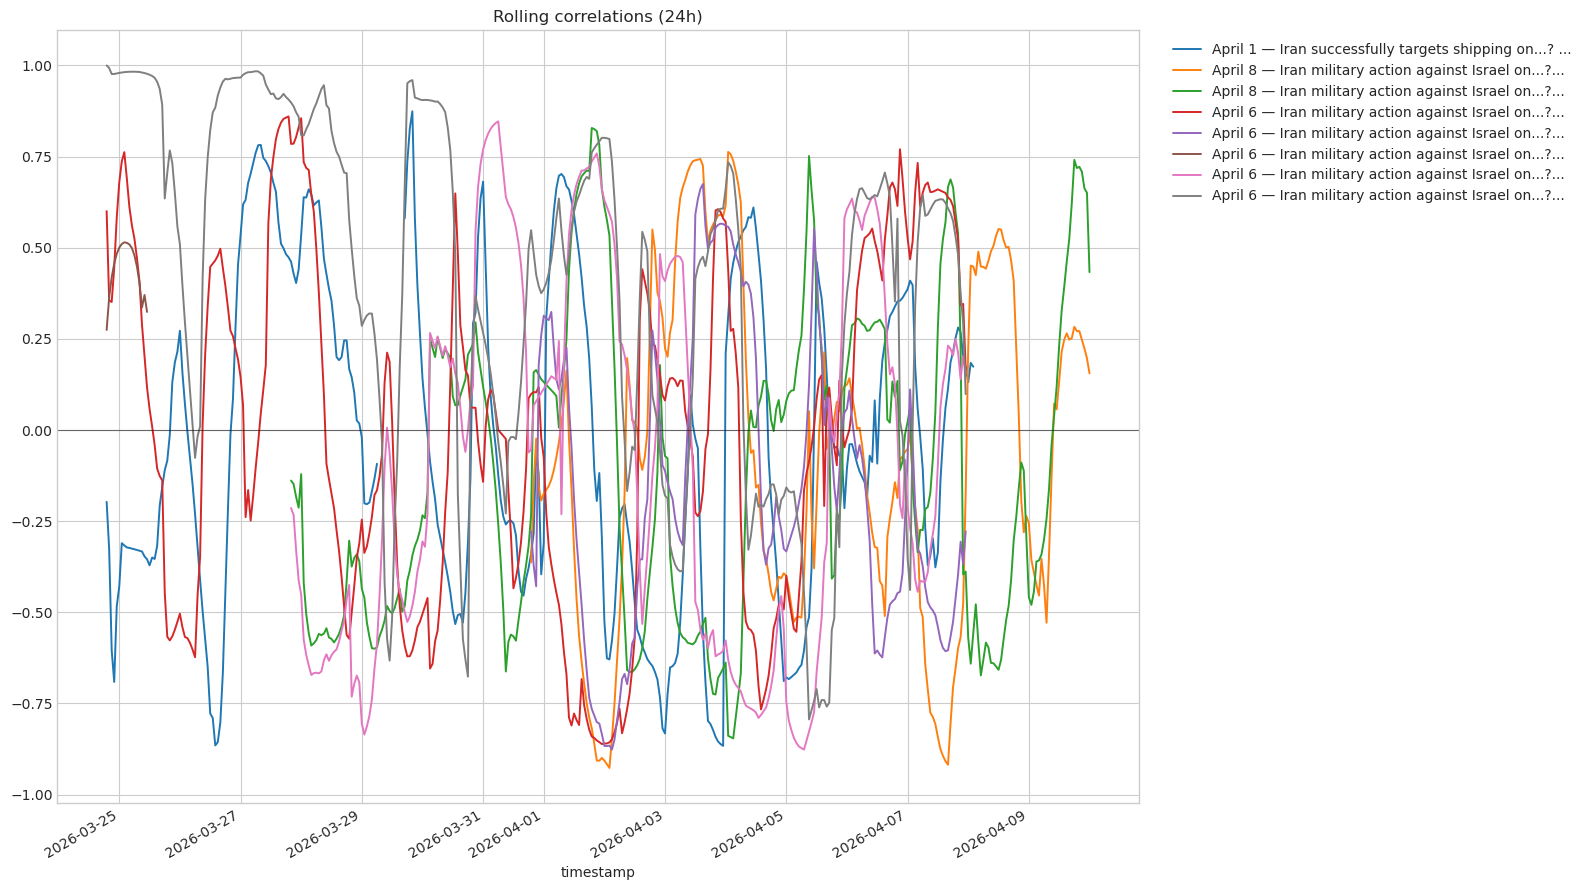

In [33]:
if rolling_pairs_df.empty:
    print("Not enough overlapping data for rolling correlations.")
else:
    latest_abs_corr = rolling_pairs_df.ffill().iloc[-1].abs().sort_values(ascending=False)
    selected_pairs = latest_abs_corr.head(min(8, len(latest_abs_corr))).index
    ax = rolling_pairs_df[selected_pairs].plot(
        figsize=(16, 9),
        linewidth=1.4,
        title=f"Rolling correlations ({rolling_window})",
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [34]:
display(market_summary)

,count,mean,std,min,max
market,,,,,
April 1 — Iran successfully targets shipping on...?,862.0,0.451299,0.351732,0.0850,0.9995
March 22 — Iran military action against a Gulf State on...?,862.0,0.788683,0.262446,0.4150,0.9995
April 9 — Military action against Iran ends on...?,862.0,0.318678,0.245285,0.0055,0.9885
April 6 — Iran military action against Israel on...?,862.0,0.629372,0.241372,0.4150,0.9995
April 8 — Iran military action against Israel on...?,862.0,0.602095,0.219744,0.4150,0.9995
April 30 — Will Trump declare war on Iran by...?,862.0,0.299998,0.217787,0.0195,0.7150
April 30 — Trump announces end of military operations against Iran by ...?,862.0,0.519014,0.120191,0.2750,0.7750
April 30 — Will another country conduct military action against Iran by...?,862.0,0.334060,0.092675,0.0600,0.4750
US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,862.0,0.148972,0.074249,0.0245,0.3325


In [35]:
pairwise_spreads = pd.DataFrame(
    {f"{left} - {right}": df[left] - df[right] for left, right in combinations(df.columns, 2)},
    index=df.index,
    dtype=float,
)

spread_summary = (
    pairwise_spreads.agg(["mean", "std", "min", "max"]).T.sort_values("std", ascending=False)
    if not pairwise_spreads.empty
    else pd.DataFrame()
)

display(spread_summary.head(10))

,mean,std,min,max
April 1 — Iran successfully targets shipping on...? - April 30 — Will Trump declare war on Iran by...?,0.151301,0.516354,-0.4800,0.9800
April 30 — Will Trump declare war on Iran by...? - March 22 — Iran military action against a Gulf State on...?,-0.488685,0.448035,-0.9800,0.0850
April 30 — Will Trump declare war on Iran by...? - April 6 — Iran military action against Israel on...?,-0.329374,0.447169,-0.9800,0.2150
April 1 — Iran successfully targets shipping on...? - April 30 — Trump announces end of military operations against Iran by ...?,-0.067715,0.429780,-0.5200,0.7110
April 1 — Iran successfully targets shipping on...? - April 9 — Military action against Iran ends on...?,0.132621,0.423935,-0.2550,0.9900
April 30 — Will Trump declare war on Iran by...? - April 8 — Iran military action against Israel on...?,-0.302097,0.423010,-0.9755,0.2750
April 1 — Iran successfully targets shipping on...? - April 30 — Will another country conduct military action against Iran by...?,0.117238,0.422409,-0.3150,0.9395
April 9 — Military action against Iran ends on...? - March 22 — Iran military action against a Gulf State on...?,-0.470005,0.396281,-0.9940,-0.0110
April 1 — Iran successfully targets shipping on...? - US-Iran nuclear deal by April 30? — US-Iran nuclear deal by April 30?,0.302327,0.384097,-0.1900,0.9635
April 1 — Iran successfully targets shipping on...? - May 31 — Israel ground operation in Iran confirmed by...?,0.204460,0.375756,-0.3300,0.8945


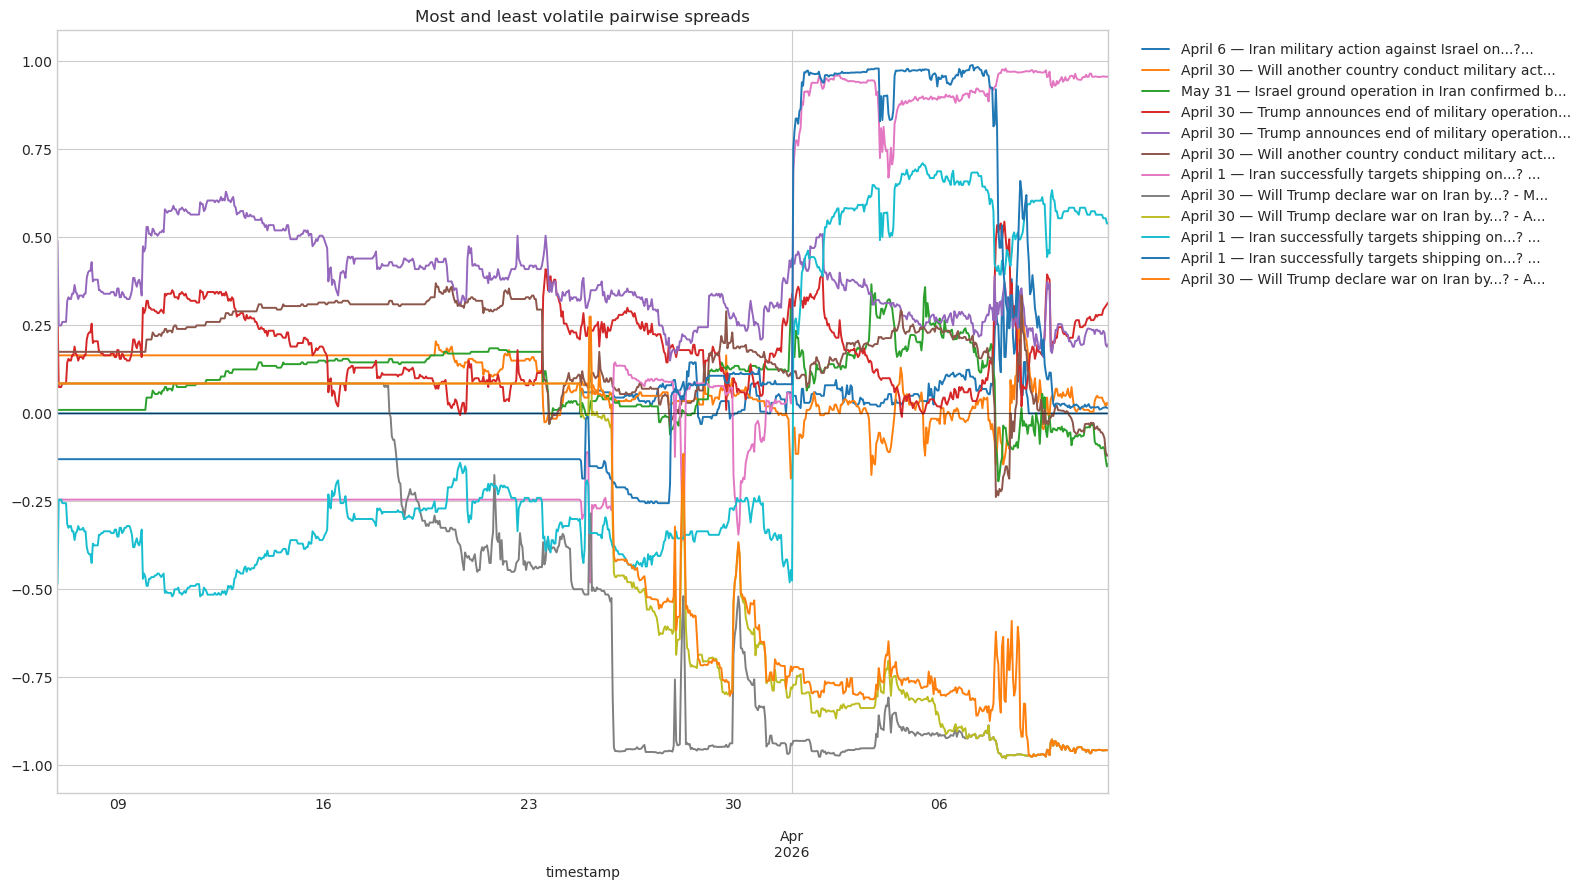

In [36]:
if spread_summary.empty:
    print("Need at least two markets to compare pairwise spreads.")
else:
    least_spreads = spread_summary.sort_values("std").head(min(6, len(spread_summary))).index
    most_spreads = spread_summary.head(min(6, len(spread_summary))).index
    selected_spreads = list(dict.fromkeys(list(least_spreads) + list(most_spreads)))

    ax = pairwise_spreads[selected_spreads].plot(
        title="Most and least volatile pairwise spreads",
        figsize=(16, 9),
        linewidth=1.4,
    )
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [ ]:
display(spread_summary.describe() if not spread_summary.empty else spread_summary)

<class 'pandas.core.series.Series'>
,Index: 36 entries, 90,000+90,000no to 2,400+2,400no
,Series name: std
,Non-Null Count  Dtype  
,--------------  -----  
,36 non-null     float64
,dtypes: float64(1)
,memory usage: 980.0+ bytes


Columns with the highest standard deviation:
,Columns with the Lowest standard deviation:


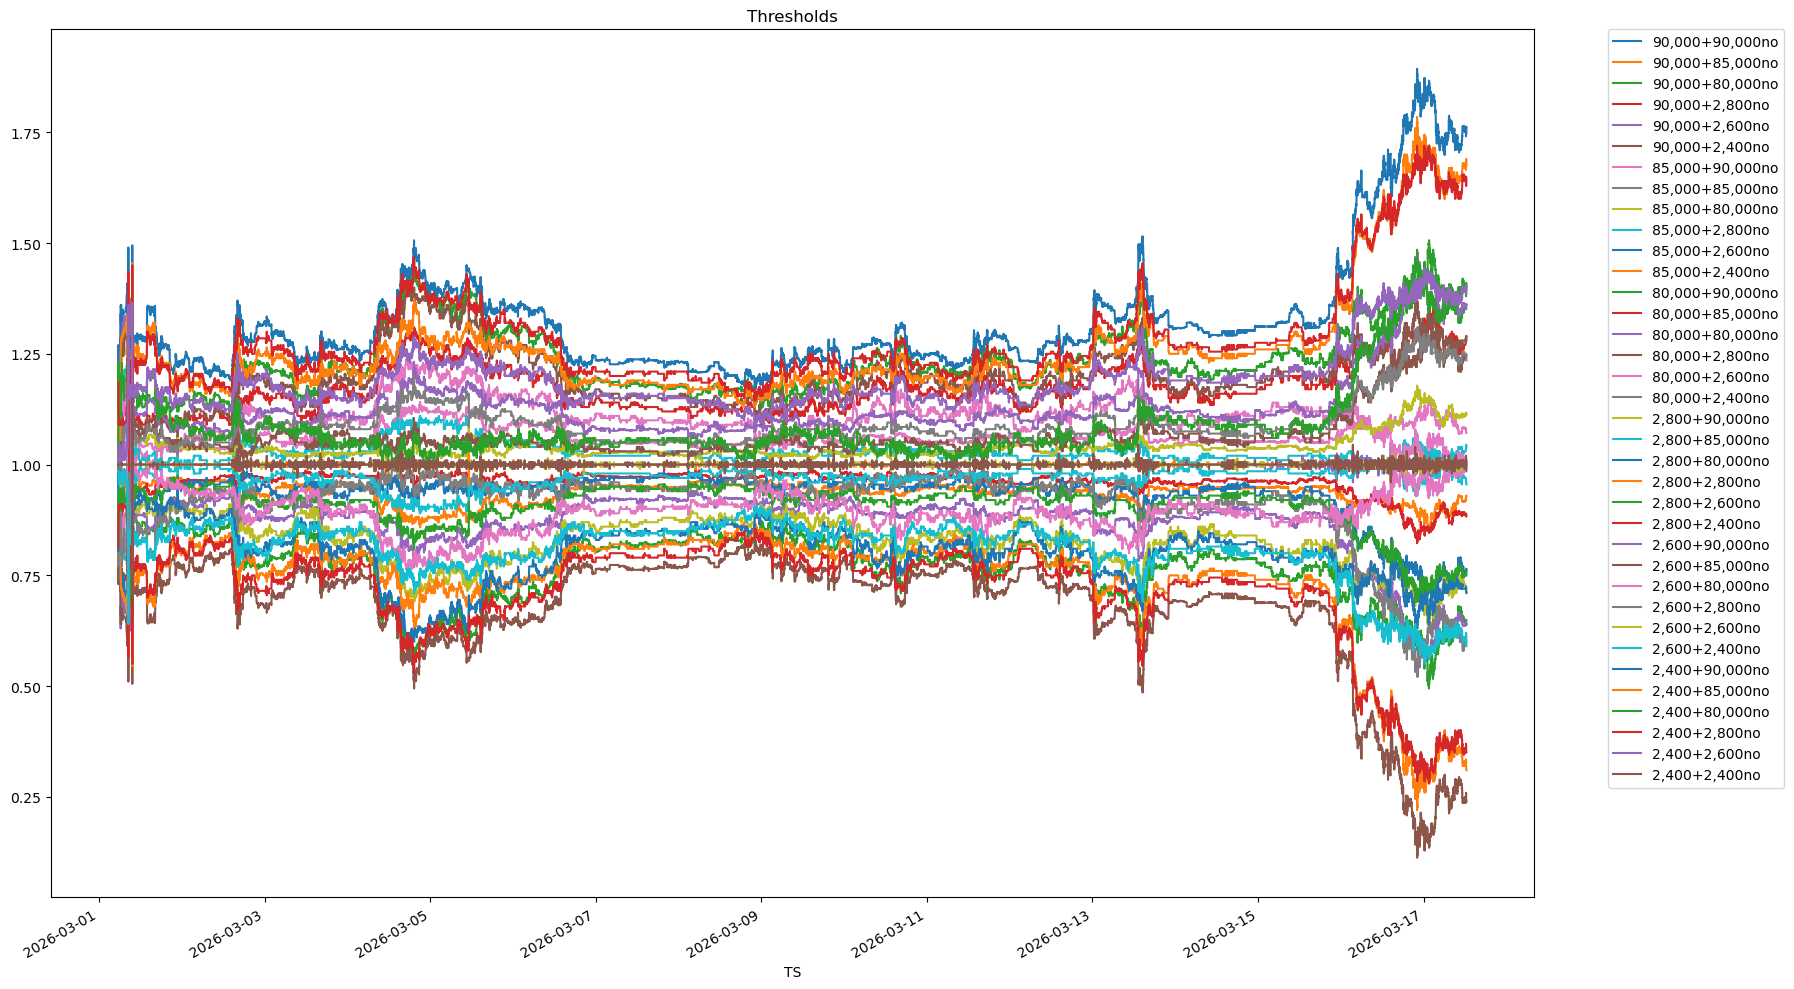

In [ ]:
selected_markets = market_summary.head(min(12, len(market_summary))).index

ax = df[selected_markets].plot(
    title="Most volatile markets",
    figsize=(16, 9),
    linewidth=1.5,
    alpha=0.9,
    legend=False,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

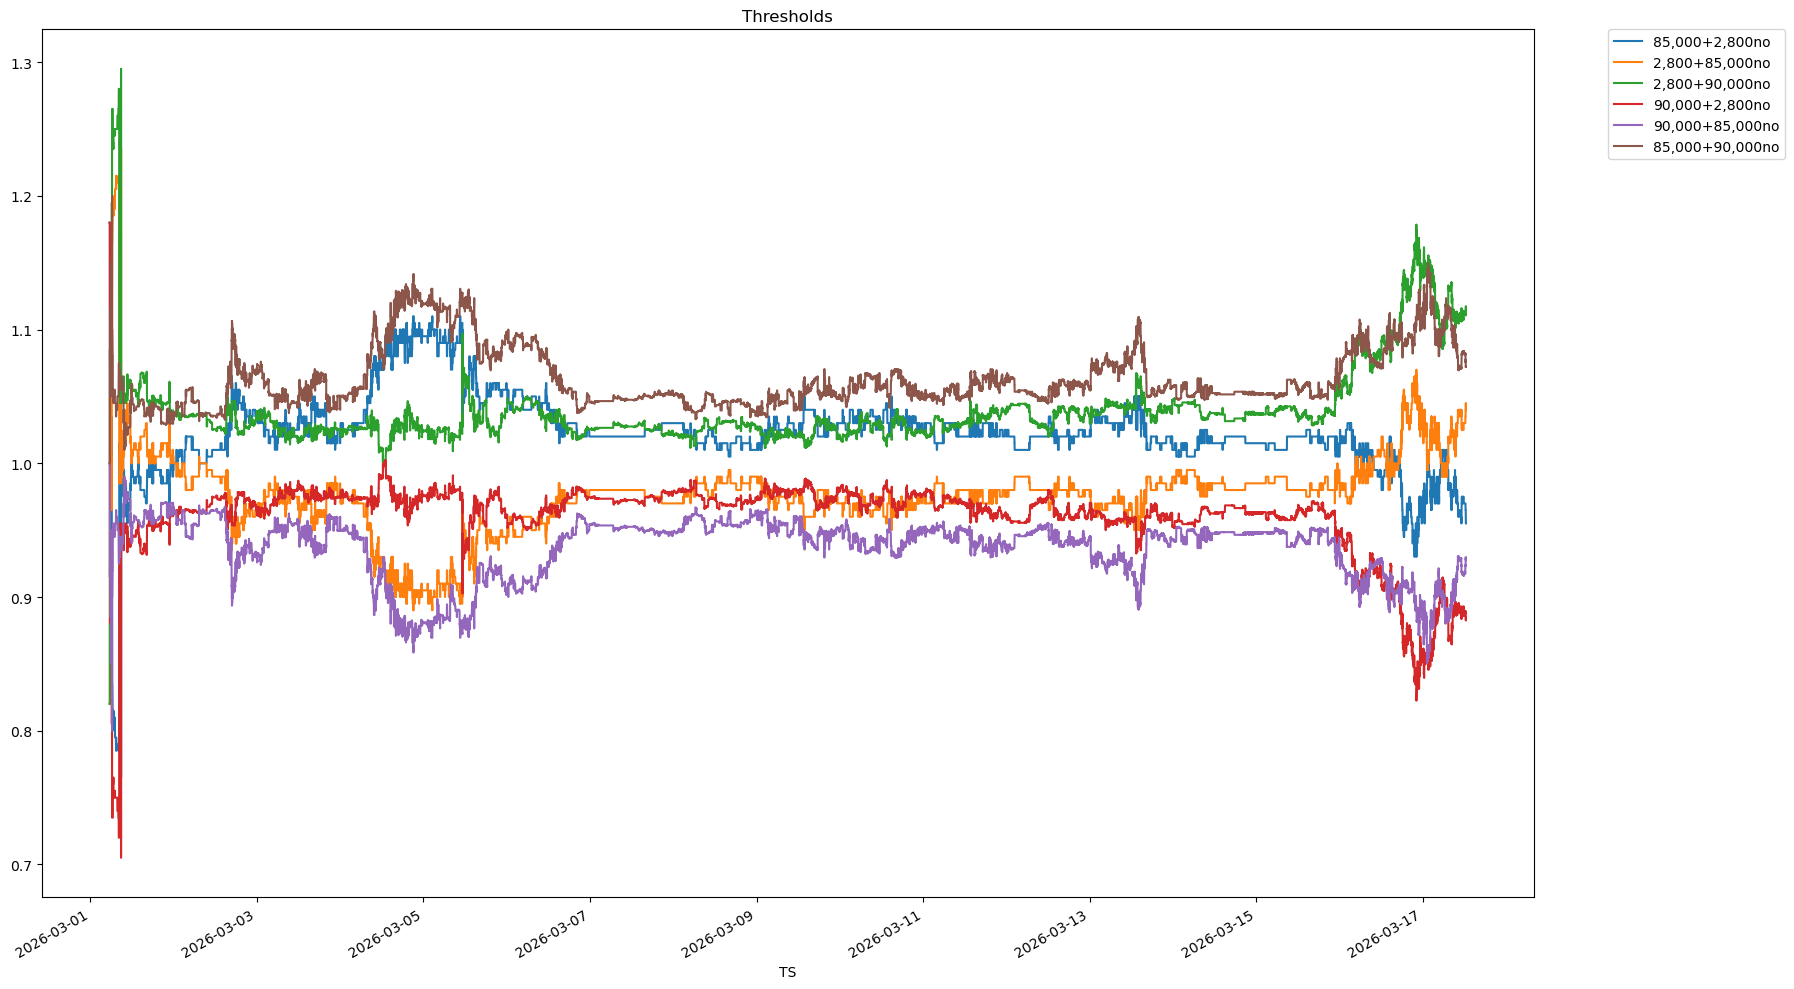

In [ ]:
selected_markets = market_summary.tail(min(12, len(market_summary))).index

ax = df[selected_markets].plot(
    title="Least volatile markets",
    figsize=(16, 9),
    linewidth=1.5,
    alpha=0.9,
    legend=False,
)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

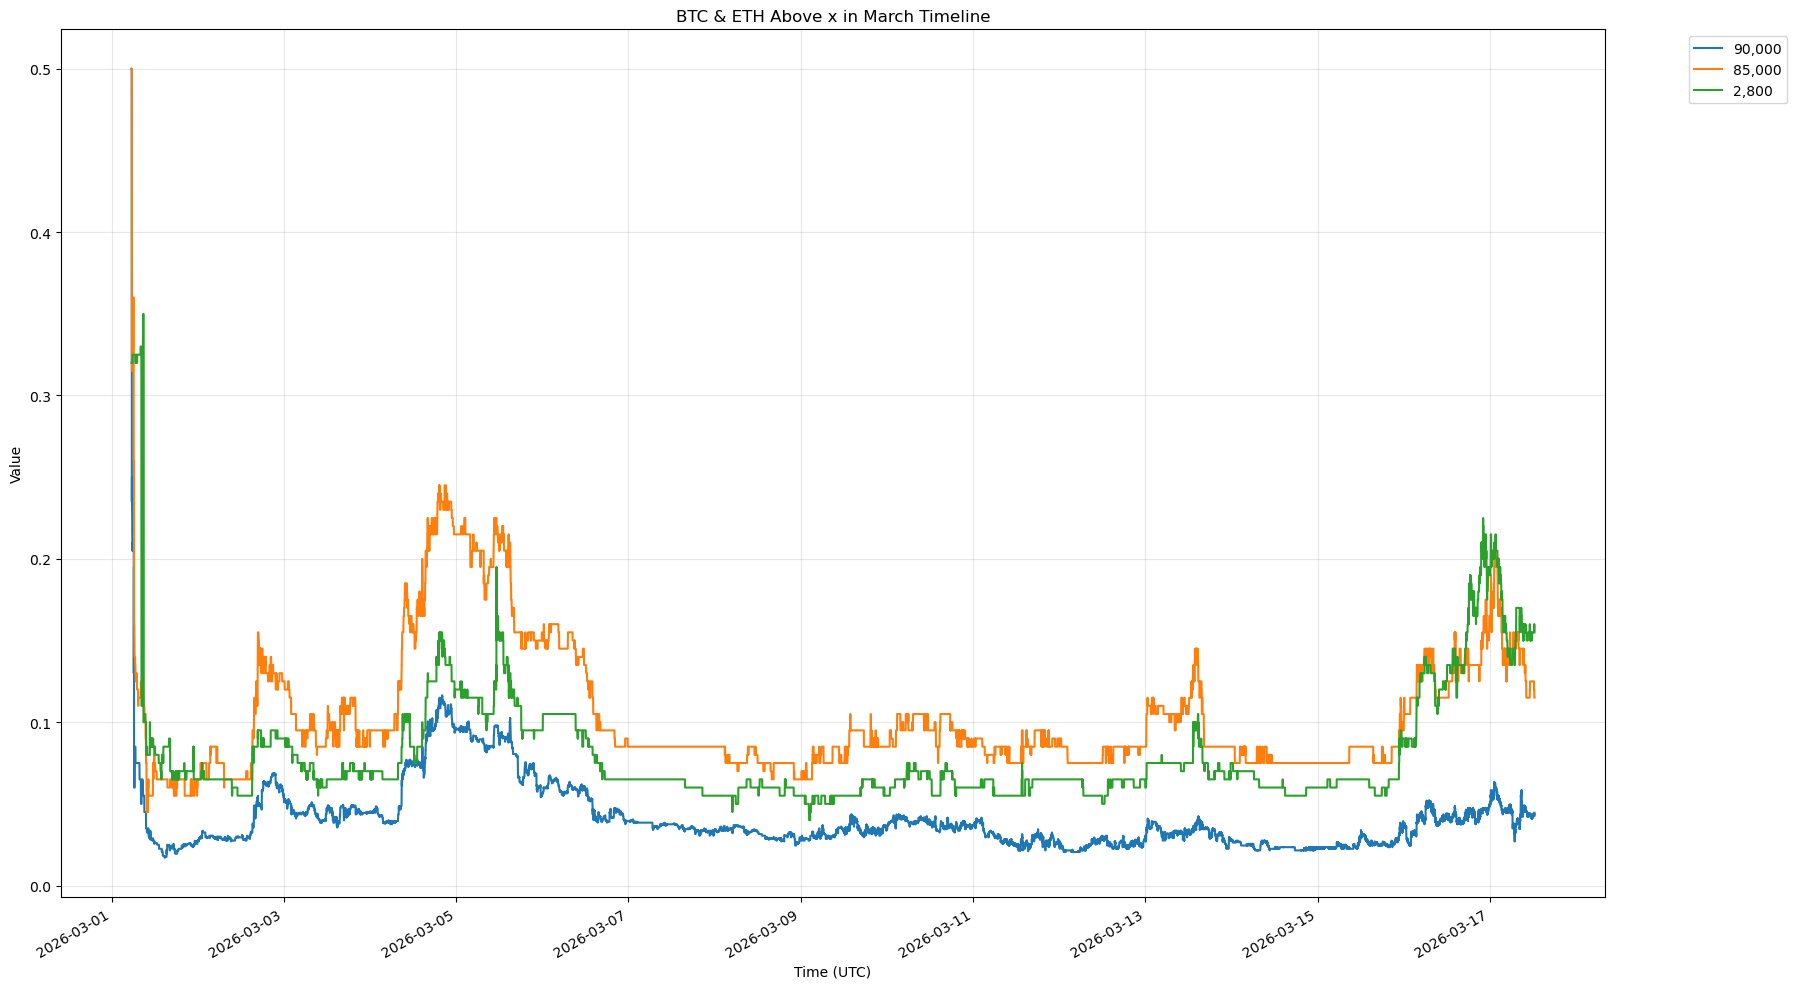

In [ ]:
top_latest = latest_snapshot.head(min(6, len(latest_snapshot))).index

ax = df[top_latest].plot(figsize=(16, 9), linewidth=1.5, alpha=0.9)
ax.set_title("Highest priced markets at the latest timestamp")
ax.set_ylabel("Probability")
ax.set_xlabel("Time (UTC)")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, wrap_labels(labels), bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()